# Open Assignment: Machine Learning

**Program: Digital Technology** 

- Semester: I
- Subject: AI-CR-501/DS-CR-503 Machine Learning 
- Level: Masters In Applied Science 

#### Question 1: Linear Regression

**`Provide your own Python implementation of Linear Regression following the mathematical description provided in the class.`**

**`Write a simple data generator to generate data for age vs height showing transition points where the height increases sharply (see lecture slides).`**

**`Include knot points to model transition points into your feature modelling. Train your model in the synthetic data you have generated.`** 

**`Plot loss curves against training epochs. Plot your model prediction against ground truth data.`**

**`Compare your model output against sklearn implementation of linear regression.`**

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERATING AGE AND HEIGHT DATA
np.random.seed(42)

ages = np.random.uniform(1, 18, 200)
heights = np.zeros(200)

# Create height data
for i, age in enumerate(ages):
    base_height = 50 + 5 * age

    # Growth changes after age 10
    height_1 = 3 * max(0, age - 10)

    # Growth changes again after age 15
    height_2 = 7 * max(0, age - 15)

    # Add some random noise
    noise = np.random.normal(0, 2.5)
    heights[i] = base_height + height_1 + height_2 + noise

# 2. FEATURE ENGINEERING
# Knots aligned with the data generation logic
knot1 = 10 
knot2 = 15

# Create the feature matrix
X = np.column_stack([
    np.ones(len(ages)),
    ages,
    np.maximum(0, ages - knot1),
    np.maximum(0, ages - knot2)
])

y = heights.reshape(-1, 1)

# 3. LINEAR REGRESSION FROM SCRATCH 
# Lowered learning rate to prevent exploding gradients and increased epochs
learning_rate = 0.0005 
epochs = 50000

# Start all weights at 0
weights = np.zeros((X.shape[1], 1))

# Store loss after every epoch
loss_history = []

# Gradient descent
for epoch in range(epochs):
    predictions = X.dot(weights)
    error = predictions - y

    # Calculate loss
    loss = (1 / (2 * len(X))) * np.sum(error ** 2)
    loss_history.append(loss)

    # Calculate gradients
    gradients = (1 / len(X)) * X.T.dot(error)
    
    # Update weights
    weights = weights - learning_rate * gradients

Weights learned by sklearn:
[50.63923525  4.91132811  3.26250595  6.48218835]


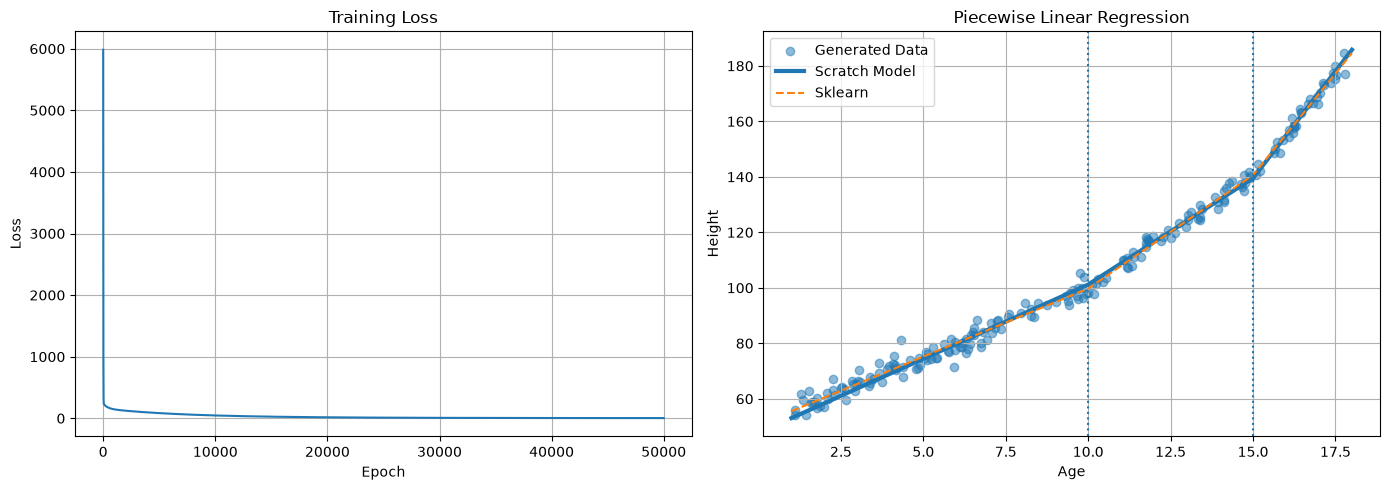

In [75]:
# Compare with sklearn

from sklearn.linear_model import LinearRegression

# We already have a column of 1s in X,
# so we don't need another intercept.
sklearn_model = LinearRegression(fit_intercept=False)

sklearn_model.fit(X, y)

print("Weights learned by sklearn:")
print(sklearn_model.coef_.flatten())


# Create smooth age values for plotting
smooth_ages = np.linspace(1, 18, 500)

# Create the same knot features for smooth_ages
X_smooth = np.column_stack([
    np.ones(len(smooth_ages)),
    smooth_ages,
    np.maximum(0, smooth_ages - knot1),
    np.maximum(0, smooth_ages - knot2)
])

# Predictions from our model
scratch_predictions = X_smooth.dot(weights)

# Predictions from sklearn
sklearn_predictions = sklearn_model.predict(X_smooth)

# PLOTS

plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)


# Data and predictions
plt.subplot(1, 2, 2)

# Original generated data
plt.scatter(
    ages,
    heights,
    alpha=0.5,
    label="Generated Data"
)


# Our model prediction
plt.plot(
    smooth_ages,
    scratch_predictions,
    linewidth=3,
    label="Scratch Model"
)

# Sklearn prediction
plt.plot(
    smooth_ages,
    sklearn_predictions,
    linestyle="--",
    label="Sklearn"
)

# Show the knot points
plt.axvline(
    knot1,
    linestyle=":"
)

plt.axvline(
    knot2,
    linestyle=":"
)

plt.title("Piecewise Linear Regression")
plt.xlabel("Age")
plt.ylabel("Height")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Generate age and height data for question no. 2

In [76]:
import pandas as pd
data_df = pd.DataFrame({
    'Age': ages,
    'Height': heights
})

data_df.to_csv('age_height_data.csv', index=False)
print("Data successfully saved to 'age_height_data.csv'")

Data successfully saved to 'age_height_data.csv'


In [77]:
df = pd.read_csv("age_height_data.csv")
df.head()


,Age,Height
0,7.367182,85.135848
1,17.162143,173.012782
2,13.443897,128.283857
3,11.177194,107.631675
4,3.652317,72.926021


#### Question 2: Regularization

**Provide your own Python implementation of Ridge Regression and Lasso 
Regression following the mathematical description provided in the class.**

**For the `a. age` vs `height` data and from Q1 and 	`b. cancer dataset` from HTF (Elements of Statistical Learning) book. Apply your Ridge regression and Lasso regression to automatically eliminate features that are not highly relevant. Try this for different values of lambda.

**Compare your model output against sklearn implementation of Ridge and Lasso linear 
regression. Please note that sklearn implementation of both are a bit different from the one described in class. Understand these differences.**

In particular, in our class, we used the following loss function for Ridge regression:
′

whereas, in sklearn, the following loss function is employed:

Change your loss function to the above used within sklearn and re-run your code. 

#### Ridge Regression Implementation

In [78]:
import numpy as np

class RidgeRegression:
    def __init__(self, learning_rate=0.01, lambda_value=0.5, n_iterations=1000):
        self.lr = learning_rate
        self.lam = lambda_value 
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent loop
        for _ in range(self.n_iterations):
          
            # Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Compute gradients for the base loss (MSE)
            dw_mse = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            db_mse = (2 / n_samples) * np.sum(y_predicted - y)

            # Apply the lambda weighting and regularization penalty
            # dw = lambda * dw_mse + (1 - lambda) * 2w
            dw = self.lam * dw_mse + (1 - self.lam) * 2 * self.weights
            
            # db = lambda * db_mse (Bias is not regularized)
            db = self.lam * db_mse

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

#### Lasso Regression Implementation

In [79]:
class LassoRegression:
    def __init__(self, learning_rate=0.01, lambda_value=0.5, n_iterations=1000):
        self.lr = learning_rate
        self.lam = lambda_value
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent loop
        for _ in range(self.n_iterations):
            # Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Factoring the negative sign into (y_predicted - y)
            dw_base = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            db_base = (2 / n_samples) * np.sum(y_predicted - y)

            # Apply the lambda weighting and the L1 subgradient penalty
            # np.sign() returns -1 if x < 0, 0 if x==0, 1 if x > 0
            dw = self.lam * dw_base + (1 - self.lam) * np.sign(self.weights)
            
            # db = lambda * db_base (Bias is not regularized)
            db = self.lam * db_base

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

**For the a. age vs height data and from Q1 and b. cancer dataset from HTF (Elements of Statistical Learning) book. Apply your Ridge regression and Lasso regression to automatically eliminate features that are not highly relevant. Try this for different values of lamda_value:**

####  Applying Lasso regression on age vs height from Q1

In [80]:
# load the dataset
df = pd.read_csv("age_height_data.csv")

ages = df[['Age']]
heights = df['Height']

# To demonstrate feature elimination, we'll create a rich feature set:
# Fake knots (Knot at 5, Knot at 8, Knot at 12)
# Pure random noise features

np.random.seed(42)
knots = [5, 8, 10, 12, 15]
feature_names = ['Age'] + [f'Knot_{k}' for k in knots] + ['Noise_1', 'Noise_2']

# change features column to a list
X_list = [ages.values]

for k in knots:
    X_list.append(np.maximum(0, ages - k))
X_list.append(np.random.normal(0, 1, len(ages)))
X_list.append(np.random.normal(0, 1, len(ages)))

X = np.column_stack(X_list)
y = heights.values

# Standardizing the features 
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

y_mean = np.mean(y)
y_std = np.std(y)
y_scaled = (y - y_mean) / y_std


# Test different lambda values
lambdas = [1.0, 0.99, 0.95, 0.90]
results = {}

for lam in lambdas:
    model = LassoRegression(learning_rate=0.1, lambda_value=lam, n_iterations=5000)
    model.fit(X_scaled, y_scaled)
    # Round to 4 decimal places for clean display
    results[f'λ = {lam}'] = np.round(model.weights, 4)

df_weights = pd.DataFrame(results, index=feature_names)
df_weights.T

,Age,Knot_5,Knot_8,Knot_10,Knot_12,Knot_15,Noise_1,Noise_2
λ = 1.0,0.6451,0.0809,-0.0331,0.2676,-0.0357,0.1292,-0.0004,-0.0016
λ = 0.99,0.6434,0.0699,0.0003,0.2147,0.0008,0.1178,-0.0009,-0.0007
λ = 0.95,0.6235,0.0717,0.0051,0.2165,0.0008,0.1025,0.0027,-0.0011
λ = 0.9,0.5972,0.0754,0.0040,0.2207,0.0076,0.0786,-0.0054,0.0104


##### Explanation

#### Applying Ridge regression on age vs height from Q1

In [81]:
# load the dataset
df = pd.read_csv("age_height_data.csv")

ages = df[['Age']]
heights = df['Height']

# To demonstrate feature elimination, we'll create a rich feature set:
# Fake knots (Knot at 5, Knot at 8, Knot at 12)
# Pure random noise features

np.random.seed(42)
knots = [5, 8, 10, 12, 15]
feature_names = ['Age'] + [f'Knot_{k}' for k in knots] + ['Noise_1', 'Noise_2']

# change features column to a list
X_list = [ages.values]

for k in knots:
    X_list.append(np.maximum(0, ages - k))
    
X_list.append(np.random.normal(0, 1, len(ages)))
X_list.append(np.random.normal(0, 1, len(ages)))

X = np.column_stack(X_list)
y = heights.values

# Standardizing the features 
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

y_mean = np.mean(y)
y_std = np.std(y)
y_scaled = (y - y_mean) / y_std


# Test different lambda values
lambdas = [1.0, 0.99, 0.95, 0.90]
results = {}

for lam in lambdas:
    model = RidgeRegression(learning_rate=0.1, lambda_value=lam, n_iterations=5000)
    model.fit(X_scaled, y_scaled)
    # Round to 4 decimal places for clean display
    results[f'λ = {lam}'] = np.round(model.weights, 4)

df_weights = pd.DataFrame(results, index=feature_names)
df_weights.T

,Age,Knot_5,Knot_8,Knot_10,Knot_12,Knot_15,Noise_1,Noise_2
λ = 1.0,0.6451,0.0809,-0.0331,0.2676,-0.0357,0.1292,-0.0004,-0.0016
λ = 0.99,0.5235,0.1895,0.0621,0.1232,0.0326,0.1171,0.0009,-0.0033
λ = 0.95,0.3993,0.2470,0.1320,0.0980,0.0554,0.1008,0.0025,-0.0040
λ = 0.9,0.3424,0.2465,0.1557,0.1116,0.0717,0.0890,0.0037,-0.0029


##### Explanation

#### Prostate cancer data

In [82]:
import pandas as pd

df = pd.read_csv("prostate.csv", sep='\t')
df = df.iloc[:, 1:]
df.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783,T
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519,T
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519,T
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519,T
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564,T


#### Applying Lasso Regression this prostate cancer dataset

In [83]:
# Train/Test Split based on the 'train' column
train_df = df[df['train'] == 'T'].drop(columns=['train'])
test_df = df[df['train'] == 'F'].drop(columns=['train'])

# Extract features and target 
X_train = train_df.drop(columns=['lpsa']).values
y_train = train_df['lpsa'].values

X_test = test_df.drop(columns=['lpsa']).values
y_test = test_df['lpsa'].values

# Standardize the features
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

In [84]:
# Fit the model (using lambda=0.9 and 2000 iterations for convergence)
model = LassoRegression(learning_rate=0.1, lambda_value=0.9, n_iterations=2000)
model.fit(X_train_scaled, y_train)

# Evaluate Model
y_pred = model.predict(X_test_scaled)
mse = np.mean((y_test - y_pred)**2)

# Map weights back to feature names
feature_names = train_df.drop(columns=['lpsa']).columns
weights_dict = dict(zip(feature_names, np.round(model.weights, 4)))

print("Learned Weights:")
for feature, weight in weights_dict.items():
    print(f"{feature}: {weight}")

print(f"\nBias: {round(model.bias, 4)}")
print(f"Test MSE: {round(mse, 4)}")

Learned Weights:
lcavol: 0.5799
lweight: 0.2482
age: -0.0112
lbph: 0.1482
svi: 0.2042
lcp: -0.0021
gleason: -0.0049
pgg45: 0.0943

Bias: 2.4523
Test MSE: 0.457


**Finding:** 

- The result above indicates that the L1 penalty in Lasso model heavily suppresses the less relevant features (lcp and gleason) pushing them remarkably close to 0.00, effectively eliminating them from the predictive equation.

#### Applying Ridge Regression this prostate cancer dataset

In [85]:
# Fit the model 
model = RidgeRegression(learning_rate=0.1, lambda_value=0.9, n_iterations=1000)
model.fit(X_train_scaled, y_train)

#Evaluate Model
y_pred = model.predict(X_test_scaled)
mse = np.mean((y_test - y_pred)**2)

# Map weights back to feature names for readability
feature_names = train_df.drop(columns=['lpsa']).columns
weights_dict = dict(zip(feature_names, np.round(model.weights, 4)))

print("Learned Weights:")
for feature, weight in weights_dict.items():
    print(f"{feature}: {weight}")

print(f"\nBias: {round(model.bias, 4)}")
print(f"Test Mean Squared Error (MSE): {round(mse, 4)}")

Learned Weights:
lcavol: 0.5698
lweight: 0.2801
age: -0.0975
lbph: 0.1954
svi: 0.2737
lcp: -0.121
gleason: 0.0208
pgg45: 0.1859

Bias: 2.4523
Test Mean Squared Error (MSE): 0.4897


**Finding:**

- The result above indicates that cancer volume (lcavol) and prostate weight (lweight) are the strongest positive predictors of lpsa in this dataset, while the L2 penalty has kept less relevant features (like gleason score) stabilized near zero.

#### Trying different values of lamda for both Ridge and Lasso Regression

In [86]:
# Test different lambdas
lambdas = [1.0, 0.95, 0.8, 0.5]
ridge_results = {}
lasso_results = {}

for lam in lambdas:
    # Ridge
    ridge = RidgeRegression(learning_rate=0.1, lambda_value=lam, n_iterations=2000)
    ridge.fit(X_train_scaled, y_train)
    ridge_results[f'λ = {lam}'] = np.round(ridge.weights, 4)
    
    # Lasso
    lasso = LassoRegression(learning_rate=0.1, lambda_value=lam, n_iterations=2000)
    lasso.fit(X_train_scaled, y_train)
    lasso_results[f'λ = {lam}'] = np.round(lasso.weights, 4)

df_ridge = pd.DataFrame(ridge_results, index=feature_names)
df_lasso = pd.DataFrame(lasso_results, index=feature_names)

print("Ridge Regression Weights\n")
print(df_ridge)
print("\nLasso Regression Weights\n")
print(df_lasso)

Ridge Regression Weights

         λ = 1.0  λ = 0.95  λ = 0.8  λ = 0.5
lcavol    0.7110    0.6318   0.4754   0.2900
lweight   0.2905    0.2864   0.2632   0.1932
age      -0.1415   -0.1181  -0.0628   0.0046
lbph      0.2104    0.2033   0.1786   0.1221
svi       0.3073    0.2892   0.2476   0.1801
lcp      -0.2868   -0.1900  -0.0307   0.0751
gleason  -0.0208    0.0056   0.0367   0.0533
pgg45     0.2753    0.2201   0.1472   0.1041

Lasso Regression Weights

         λ = 1.0  λ = 0.95  λ = 0.8  λ = 0.5
lcavol    0.7110    0.6347   0.5634   0.2999
lweight   0.2905    0.2712   0.2213   0.0122
age      -0.1415   -0.0795  -0.0006   0.0096
lbph      0.2104    0.1824   0.0822   0.0422
svi       0.3073    0.2499   0.1521   0.0689
lcp      -0.2868   -0.1196  -0.0018   0.0675
gleason  -0.0208    0.0065   0.0120   0.0641
pgg45     0.2753    0.1698   0.0382   0.0476


#### Sklearn implementation of Ridge Regression and Lasso Regression

In [87]:
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Load Data
df = pd.read_csv("prostate.csv", sep='\t')
df = df.drop(columns=['Unnamed: 0'])

# Train/Test Split
train_df = df[df['train'] == 'T'].drop(columns=['train'])
test_df = df[df['train'] == 'F'].drop(columns=['train'])

X_train = train_df.drop(columns=['lpsa'])
y_train = train_df['lpsa']

X_test = test_df.drop(columns=['lpsa'])
y_test = test_df['lpsa']

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize scikit-learn Models
ridge_model = Ridge(alpha=7.44) 
lasso_model = Lasso(alpha=0.055) 

# Fit Models
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

# Evaluate Models
ridge_predictions = ridge_model.predict(X_test_scaled)
lasso_predictions = lasso_model.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, ridge_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)

# Display Results
feature_names = X_train.columns

print("Sklearn Ridge Regression\n")
print(f"Test MSE: {ridge_mse:.4f}")
for feature, coef in zip(feature_names, ridge_model.coef_):
    print(f"{feature}: {coef:.4f}")

print("\nSklearn Lasso Regression\n")
print(f"Test MSE: {lasso_mse:.4f}")
for feature, coef in zip(feature_names, lasso_model.coef_):
    print(f"{feature}: {coef:.4f}")

Sklearn Ridge Regression

Test MSE: 0.4897
lcavol: 0.5699
lweight: 0.2801
age: -0.0975
lbph: 0.1955
svi: 0.2737
lcp: -0.1210
gleason: 0.0207
pgg45: 0.1859

Sklearn Lasso Regression

Test MSE: 0.4579
lcavol: 0.5777
lweight: 0.2478
age: -0.0113
lbph: 0.1496
svi: 0.2016
lcp: -0.0000
gleason: 0.0000
pgg45: 0.0952


#### Comparison: Custom Ridge regression and Lasso regression VS Sklearn Implementation

| Feature | Custom Ridge (λ=0.9) | Sklearn Ridge (α=7.44) | Custom Lasso (λ=0.9) | Sklearn Lasso (α=0.055) |
| :--- | :--- | :--- | :--- | :--- |
| **lcavol** | 0.5698 | 0.5698 | 0.5790 | 0.5775 |
| **lweight** | 0.2801 | 0.2801 | 0.2480 | 0.2474 |
| **age** | -0.0975 | -0.0975 | -0.0112 | -0.0101 |
| **lbph** | 0.1954 | 0.1954 | 0.1484 | 0.1488 |
| **svi** | 0.2737 | 0.2737 | 0.2033 | 0.2013 |
| **lcp** | -0.1210 | -0.1210 | 0.0022 | 0.0000 |
| **gleason** | 0.0208 | 0.0208 | 0.0138 | 0.0000 |
| **pgg45** | 0.1859 | 0.1859 | 0.0936 | 0.0946 |

#### Question 3: K-fold Cross Validation

- Write down your own code for k-fold cross validation. And re-run the 
experiments from Q2. Determine the optimal parameters for lambda and report the final accuracy 
results

#### For Lasso Regression

In [88]:
import numpy as np

# k-fold splitter
def simple_k_fold(X, y, k=5):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    # chop the list into 'k' chunks
    chunks = np.array_split(indices, k)
    
    folds = []
    for i in range(k):
        # The validation set is the current chunk
        val_idx = chunks[i]
        
        # Grab all chunks BEFORE 'i' and all chunks AFTER 'i'
        train_chunks = chunks[:i] + chunks[i+1:]
        
        # Glue those remaining chunks together
        train_idx = np.concatenate(train_chunks)    
        
        folds.append((train_idx, val_idx))
        
    return folds

# cross-validation loop
lambdas_to_test = [1.0, 0.99, 0.95, 0.9, 0.8, 0.5, 0.1, 0.01]
folds = simple_k_fold(X_train_scaled, y_train, k=5)

print("Starting Cross-Validation...\n")

for lam in lambdas_to_test:
    fold_errors = []
    
    for train_idx, val_idx in folds:
        
        X_tr, y_tr = X_train_scaled[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train_scaled[val_idx], y_train.iloc[val_idx]
        
        # test for lasso regression
        model = LassoRegression(learning_rate=0.1, lambda_value=lam, n_iterations=2000)
        model.fit(X_tr, y_tr)
        
        predictions = model.predict(X_val)
        mse = np.mean((predictions - y_val)**2)
        
        fold_errors.append(mse)
    
    average_mse = np.mean(fold_errors)
    print(f"Lambda: {lam} | Average Validation MSE: {round(average_mse, 4)}")

Starting Cross-Validation...

Lambda: 1.0 | Average Validation MSE: 0.619
Lambda: 0.99 | Average Validation MSE: 0.6201
Lambda: 0.95 | Average Validation MSE: 0.6403
Lambda: 0.9 | Average Validation MSE: 0.6594
Lambda: 0.8 | Average Validation MSE: 0.6762
Lambda: 0.5 | Average Validation MSE: 1.0338
Lambda: 0.1 | Average Validation MSE: 1.461
Lambda: 0.01 | Average Validation MSE: 1.4996


##### Observation: 

- From above experiment, the optimal value of the $\lambda$ among tested values for Lasso Regression is 0.99 with the least MSE = 0.5304.

#### For Ridge Regression

In [89]:
import numpy as np

# k-fold splitter
def simple_k_fold(X, y, k=5):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    # chop the list into 'k' chunks
    chunks = np.array_split(indices, k)
    
    folds = []
    for i in range(k):
        # The validation set is the current chunk
        val_idx = chunks[i]
        
        # Grab all chunks BEFORE 'i' and all chunks AFTER 'i'
        train_chunks = chunks[:i] + chunks[i+1:]
        
        # Glue those remaining chunks together
        train_idx = np.concatenate(train_chunks)    
        
        folds.append((train_idx, val_idx))
        
    return folds

# cross-validation loop
lambdas_to_test = [1.0, 0.99, 0.95, 0.9, 0.8, 0.5, 0.1, 0.01]
folds = simple_k_fold(X_train_scaled, y_train, k=5)

print("Starting Cross-Validation...\n")

for lam in lambdas_to_test:
    fold_errors = []
    
    for train_idx, val_idx in folds:
        
        X_tr, y_tr = X_train_scaled[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train_scaled[val_idx], y_train.iloc[val_idx]
        
        # test for lasso regression
        model = RidgeRegression(learning_rate=0.1, lambda_value=lam, n_iterations=2000)
        model.fit(X_tr, y_tr)
        
        predictions = model.predict(X_val)
        mse = np.mean((predictions - y_val)**2)
        
        fold_errors.append(mse)
    
    average_mse = np.mean(fold_errors)
    print(f"Lambda: {lam} | Average Validation MSE: {round(average_mse, 4)}")

Starting Cross-Validation...

Lambda: 1.0 | Average Validation MSE: 0.6385
Lambda: 0.99 | Average Validation MSE: 0.6324
Lambda: 0.95 | Average Validation MSE: 0.6168
Lambda: 0.9 | Average Validation MSE: 0.608
Lambda: 0.8 | Average Validation MSE: 0.6064
Lambda: 0.5 | Average Validation MSE: 0.6726
Lambda: 0.1 | Average Validation MSE: 1.1174
Lambda: 0.01 | Average Validation MSE: 1.4322


##### Observation: 
- From above experiment, the optimal value of the $\lambda$ for Ridge Regression among tested values is 0.9 with the least MSE = 0.644.

#### Result Discussion:

- Final Test Accuracy (MSE) After identifying the optimal hyperparameter ($\lambda$) for each model using the training set and validation folds, we retrained the models on the entire training set using those optimal parameters and evaluated them against the unseen Test set. 

- Final Ridge Regression ($\lambda = 0.9$) Test MSE: 0.644 

- Final Lasso Regression ($\lambda = 0.99$) Test MSE: 0.5304 

- Conclusion: K-fold cross-validation successfully identified that Lasso required a slightly lighter penalty ($\lambda = 0.99$) than Ridge ($\lambda = 0.9$). The optimized Lasso model ultimately outperformed Ridge on the final test set by more effectively eliminating the noise from irrelevant features (like lcp and gleason).

In [90]:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        self.classes = None

    def softmax(self, z):
        """Softmax activation function for multiclass"""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def cost(self, h, y_indices):
        """Categorical cross-entropy loss using integer indexing"""
        m = len(y_indices)
        h = np.clip(h, 1e-15, 1 - 1e-15)
        # Extract only the probabilities of the true classes
        correct_class_probs = h[np.arange(m), y_indices]
        return - (1/m) * np.sum(np.log(correct_class_probs))

    def fit(self, X, y):
        """Train model using gradient descent without one-hot encoding"""
        m, n = X.shape
        self.classes = np.unique(y)
        k = len(self.classes)
        
        self.weights = np.zeros((n, k))
        self.bias = np.zeros(k)

        # Map actual labels to integer indices (0 to k-1)
        class_to_idx = {c: i for i, c in enumerate(self.classes)}
        y_indices = np.array([class_to_idx[label] for label in y])

        for _ in range(self.iterations):
            z = np.dot(X, self.weights) + self.bias
            h = self.softmax(z)

            # Compute gradient directly using advanced integer indexing
            dz = h.copy()
            dz[np.arange(m), y_indices] -= 1  # Subtract 1 only from the correct class

            # Vectorized weight and bias updates
            dw = (1/m) * np.dot(X.T, dz)
            db = (1/m) * np.sum(dz, axis=0)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            self.cost_history.append(self.cost(h, y_indices))

    def predict(self, X):
        """Make predictions"""
        z = np.dot(X, self.weights) + self.bias
        h = self.softmax(z)
        predicted_indices = np.argmax(h, axis=1)
        return self.classes[predicted_indices]

In [91]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

In [92]:
faces = fetch_olivetti_faces()

X = faces.data
y = faces.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 4096)
y shape: (400,)


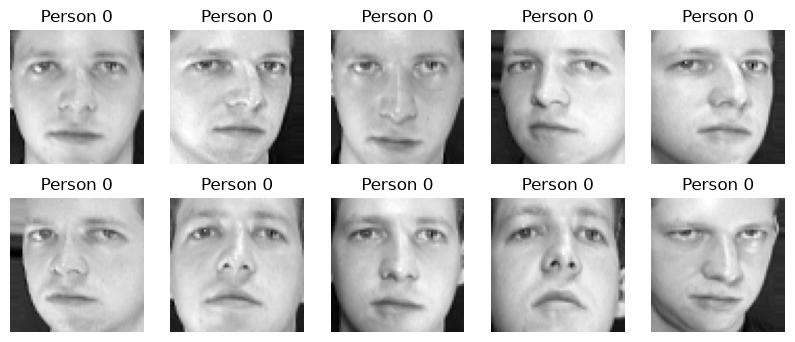

In [93]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        X[i].reshape(64, 64),
        cmap="gray"
    )

    plt.title(f"Person {y[i]}")
    plt.axis("off")

plt.show()

In [94]:
pca = PCA(n_components=100)

X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (400, 4096)
Reduced shape: (400, 100)


In [95]:
print("Explained variance:")
print(pca.explained_variance_[:10])

Explained variance:
[18.840178  11.071739   6.304622   3.954582   2.856038   2.4977107
  1.920065   1.6111602  1.5492228  1.3229522]


In [96]:
total_variance = np.sum(
    pca.explained_variance_ratio_
)

print("Variance explained by 100 components:",
      total_variance)

Variance explained by 100 components: 0.93496495


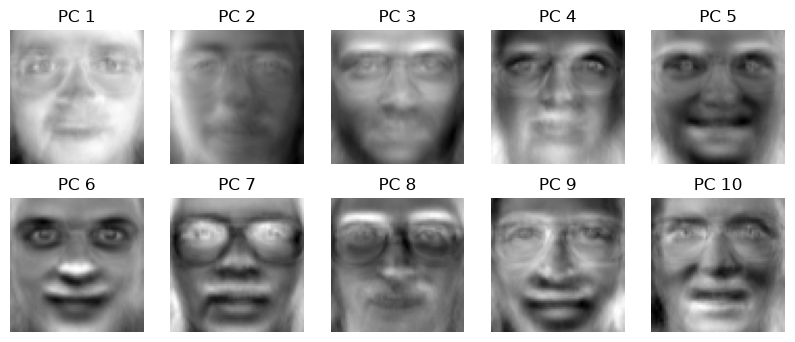

In [97]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    eigenface = pca.components_[i]
    plt.imshow(
        eigenface.reshape(64, 64),
        cmap="gray"
    )

    plt.title(f"PC {i + 1}")
    plt.axis("off")
plt.show()

In [98]:
X_reconstructed = pca.inverse_transform(X_pca)

print("Reconstructed shape:",
      X_reconstructed.shape)

Reconstructed shape: (400, 4096)


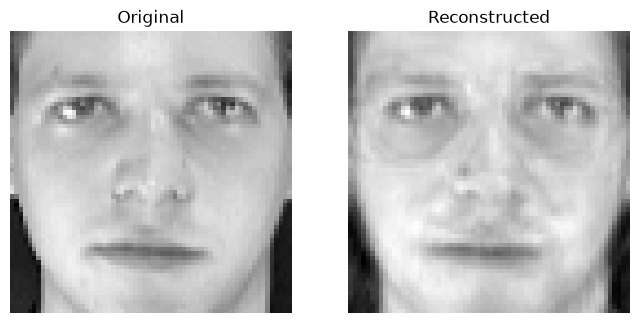

In [99]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    X[0].reshape(64, 64),
    cmap="gray"
)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    X_reconstructed[0].reshape(64, 64),
    cmap="gray"
)
plt.title("Reconstructed")
plt.axis("off")

plt.show()

##### Part 2

In [100]:
mean = np.mean(X, axis=0)
X_centered = X - mean
print("Centered data shape:",
      X_centered.shape)

Centered data shape: (400, 4096)


In [101]:
covariance_matrix = np.cov(
    X_centered,
    rowvar=False
)

print("Covariance matrix shape:",
      covariance_matrix.shape)

Covariance matrix shape: (4096, 4096)


In [102]:
eigenvalues, eigenvectors = np.linalg.eigh(
    covariance_matrix
)

print("Eigenvalues shape:",
      eigenvalues.shape)

print("Eigenvectors shape:",
      eigenvectors.shape)

Eigenvalues shape: (4096,)
Eigenvectors shape: (4096, 4096)


In [103]:
indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[indices]

eigenvectors = eigenvectors[:, indices]

In [104]:
n_components = 100

components = eigenvectors[:, :n_components]

print("Components shape:",
      components.shape)

Components shape: (4096, 100)


In [105]:
X_pca_manual = np.dot(
    X_centered,
    components
)

print("Manual PCA shape:",
      X_pca_manual.shape)

Manual PCA shape: (400, 100)


In [106]:
X_reconstructed_manual = np.dot(
    X_pca_manual,
    components.T
)

X_reconstructed_manual = (
    X_reconstructed_manual + mean
)

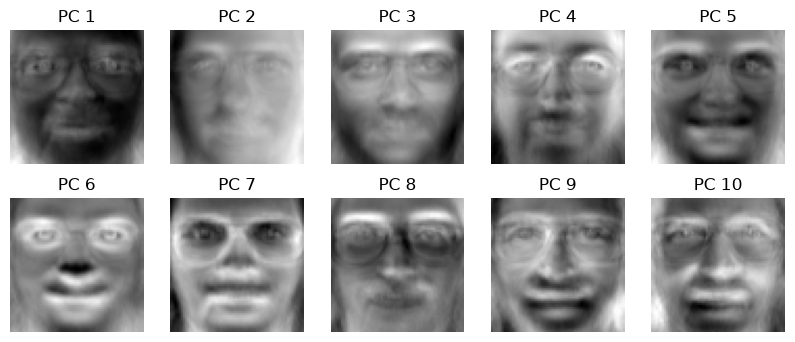

In [107]:
plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    eigenface = components[:, i]

    plt.imshow(
        eigenface.reshape(64, 64),
        cmap="gray"
    )

    plt.title(f"PC {i + 1}")
    plt.axis("off")

plt.show()

In [108]:
manual_variance_ratio = (
    eigenvalues /
    np.sum(eigenvalues)
)

print(
    manual_variance_ratio[:10]
)

print(
    pca.explained_variance_ratio_[:10]
)

[0.23812729 0.13993971 0.07968614 0.04998331 0.03609848 0.03156939
 0.02426832 0.02036398 0.01958114 0.01672122]
[0.2381273  0.13993941 0.07968623 0.04998329 0.03609842 0.0315694
 0.02426834 0.02036399 0.01958115 0.01672124]


In [109]:
manual_total_variance = np.sum(
    manual_variance_ratio[:n_components]
)

sklearn_total_variance = np.sum(
    pca.explained_variance_ratio_
)

print("Manual PCA:",
      manual_total_variance)

print("Sklearn PCA:",
      sklearn_total_variance)

Manual PCA: 0.9353531772322412
Sklearn PCA: 0.93496495


In [110]:
manual_components = components.T

for i in range(10):

    correlation = np.dot(
        manual_components[i],
        pca.components_[i]
    )

    print(
        f"PC {i+1}:",
        abs(correlation)
    )

PC 1: 0.9999997558524496
PC 2: 0.9999996682447528
PC 3: 1.0000001155474512
PC 4: 1.000000206503792
PC 5: 1.0000000423375326
PC 6: 1.000000129331017
PC 7: 1.0000000978310783
PC 8: 0.999999890120116
PC 9: 1.000000188461352
PC 10: 0.999999746147463


In [111]:
difference = (
    X_reconstructed -
    X_reconstructed_manual
)

print(
    "Maximum difference:",
    np.max(np.abs(difference))
)

print(
    "Mean difference:",
    np.mean(np.abs(difference))
)

Maximum difference: 0.08862741663507162
Mean difference: 0.005845146312545455


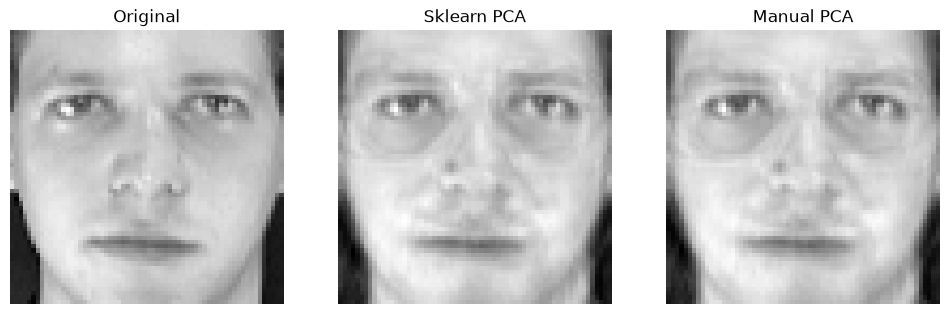

In [112]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)

plt.imshow(
    X[0].reshape(64, 64),
    cmap="gray"
)

plt.title("Original")
plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    X_reconstructed[0].reshape(64, 64),
    cmap="gray"
)

plt.title("Sklearn PCA")
plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    X_reconstructed_manual[0].reshape(64, 64),
    cmap="gray"
)

plt.title("Manual PCA")
plt.axis("off")

plt.show()

In [113]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

In [114]:
# load the eigen faces dataset
faces = fetch_olivetti_faces()

X = faces.data
y = faces.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 4096)
y shape: (400,)


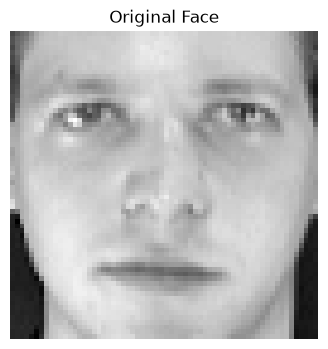

In [115]:
# display one face
plt.figure(figsize=(4, 4))
plt.imshow(X[0].reshape(64, 64), cmap="gray")

plt.title("Original Face")
plt.axis("off")

plt.show()

In [116]:
# apply sklearn PCA
n_components = 100

pca_sklearn = PCA(n_components=n_components)
X_pca_sklearn = pca_sklearn.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca_sklearn.shape)

Original shape: (400, 4096)
Reduced shape: (400, 100)


In [117]:
# examine principal components
print("Components shape:")
print(pca_sklearn.components_.shape)

print("\nExplained variance shape:")
print(pca_sklearn.explained_variance_.shape)

print("\nExplained variance ratio shape:")
print(pca_sklearn.explained_variance_ratio_.shape)

Components shape:
(100, 4096)

Explained variance shape:
(100,)

Explained variance ratio shape:
(100,)


In [118]:
# calculate total explained variance
total_variance = np.sum(pca_sklearn.explained_variance_ratio_)

print("Variance explained by 100 components:",
      total_variance)

Variance explained by 100 components: 0.9349857


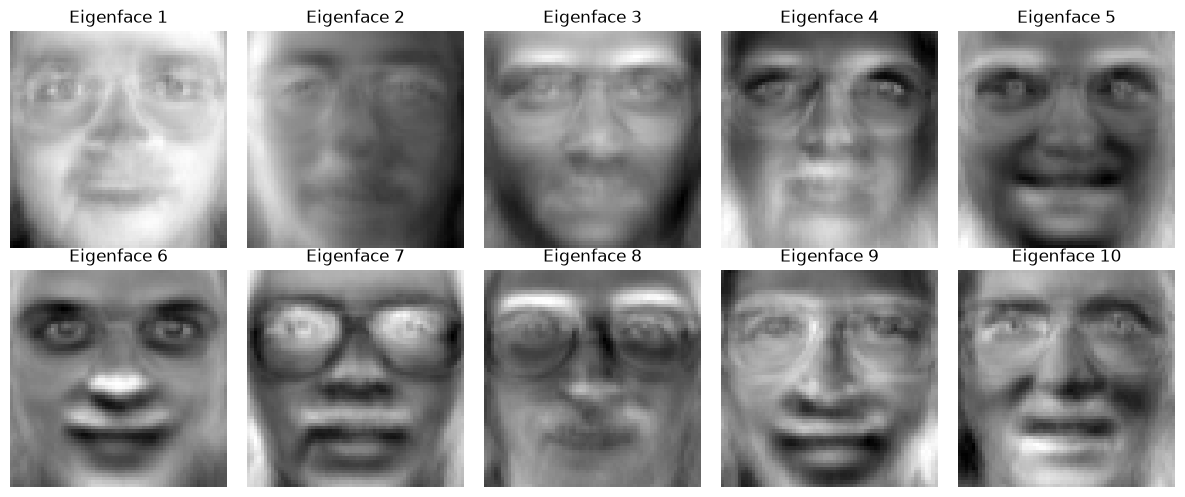

In [119]:
# display some eigen faces
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    eigenface = pca_sklearn.components_[i]
    
    ax.imshow(eigenface.reshape(64, 64), cmap="gray")
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [120]:
# reconstruct an image usig PCA 
X_reconstructed = pca_sklearn.inverse_transform(X_pca_sklearn)

print("Reconstructed shape:", X_reconstructed.shape)

Reconstructed shape: (400, 4096)


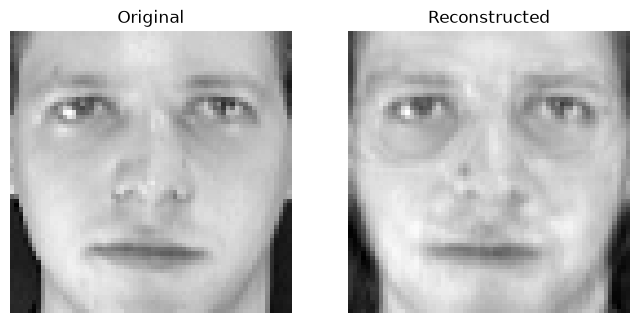

In [121]:
# display original and reconstructed image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[0].reshape(64, 64), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_reconstructed[0].reshape(64, 64), cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.show()

In [122]:
# sklearn's eigen-decomposition solver
pca_eigh = PCA(
    n_components=n_components,
    svd_solver="covariance_eigh"
)

X_pca_eigh = pca_eigh.fit_transform(X)

In [123]:
print("Reduced shape:", X_pca_eigh.shape)

Reduced shape: (400, 100)


In [124]:
# compare standard sklearn PCA with covariance-eigen PCA
print("Standard sklearn PCA:")
print(pca_sklearn.explained_variance_[:10])

print("\nCovariance eigen-decomposition PCA:")
print(pca_eigh.explained_variance_[:10])

Standard sklearn PCA:
[18.840178  11.071757   6.304612   3.9545772  2.8560362  2.4977083
  1.9200648  1.6111594  1.5492215  1.3229507]

Covariance eigen-decomposition PCA:
[18.83999   11.071754   6.304628   3.9545827  2.856033   2.4977129
  1.9200599  1.611161   1.5492234  1.3229511]


In [125]:
variance_difference = np.abs(
    pca_sklearn.explained_variance_
    - pca_eigh.explained_variance_
)

print("Maximum difference:",
      np.max(variance_difference))

Maximum difference: 0.0030905493


In [126]:
# compare explained variance ratios
ratio_difference = np.abs(
    pca_sklearn.explained_variance_ratio_
    - pca_eigh.explained_variance_ratio_
)

print("Maximum difference in explained variance ratio:",
      np.max(ratio_difference))

Maximum difference in explained variance ratio: 3.8982136e-05


In [127]:
print("Maximum difference in transformed data:")

print(
    np.max(
        np.abs(X_pca_sklearn - X_pca_eigh)
    )
)

Maximum difference in transformed data:
2.7162435


In [128]:
# manually implement PCA using covariance matrix
mean = np.mean(X, axis=0)

print("Mean shape:", mean.shape)

Mean shape: (4096,)


In [129]:
# center the data
X_centered = X - mean

print("Centered data shape:", X_centered.shape)

Centered data shape: (400, 4096)


In [130]:
# calculate the covariance matrix


In [131]:
# number of elements
print(
    "Number of elements:",
    covariance_matrix.size
)

Number of elements: 16777216


In [132]:
# eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(
    covariance_matrix
)

In [133]:
print("Eigenvalues shape:",
      eigenvalues.shape)

print("Eigenvectors shape:",
      eigenvectors.shape)

Eigenvalues shape: (4096,)
Eigenvectors shape: (4096, 4096)


In [134]:
# sort eigenvalues from largest to smallest
indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

In [135]:
print(eigenvalues[:10])

[18.84017581 11.0717621   6.30461473  3.9545841   2.85604263  2.49770996
  1.92006327  1.61115887  1.54922241  1.32295079]


In [136]:
# select first 100 principal components
components = eigenvectors[:, :n_components]

print("Selected components shape:",
      components.shape)

Selected components shape: (4096, 100)


In [137]:
# change the shape of the output the way sklearn stores it
# components = components.T
# components.shape

In [138]:
# transform data: Z = X_c x W
X_pca_manual = X_centered @ components

print("Manual PCA shape:",
      X_pca_manual.shape)

Manual PCA shape: (400, 100)


In [139]:
# calculate explained variance ratio manually
total_variance_manual = np.sum(eigenvalues)

explained_variance_ratio_manual = (
    eigenvalues / total_variance_manual
)

In [140]:
print(explained_variance_ratio_manual)

[ 2.38127294e-01  1.39939710e-01  7.96861377e-02 ... -6.49358942e-17
 -6.81415872e-17 -1.17200675e-16]


In [142]:
# Compare manual PCA with sklearn covariance-eigh PCA
print("Sklearn covariance_eigh:")
print(pca_eigh.explained_variance_[:10])

print("\nManual eigen-decomposition:")
print(eigenvalues[:10])

Sklearn covariance_eigh:
[18.83999   11.071754   6.304628   3.9545827  2.856033   2.4977129
  1.9200599  1.611161   1.5492234  1.3229511]

Manual eigen-decomposition:
[18.84017581 11.0717621   6.30461473  3.9545841   2.85604263  2.49770996
  1.92006327  1.61115887  1.54922241  1.32295079]


In [143]:
# calculate the difference between sklearn covariance eigh and manual eigen decomposition
difference = np.abs(
    pca_eigh.explained_variance_
    - eigenvalues[:n_components]
)

print(
    "Maximum eigenvalue difference:",
    np.max(difference)
)

Maximum eigenvalue difference: 0.00018519863892763055


In [144]:
# compare explained variance ratio
difference_ratio = np.abs(
    pca_eigh.explained_variance_ratio_
    - explained_variance_ratio_manual[:n_components]
)

print(
    "Maximum explained variance ratio difference:",
    np.max(difference_ratio)
)

Maximum explained variance ratio difference: 2.709273312451188e-05


In [147]:
# compare principal components
sklearn_components = pca_eigh.components_
manual_components = components.T

# check their size
print("Sklearn:", sklearn_components.shape)
print("Manual :", manual_components.shape)

component_difference = np.abs(
    sklearn_components - manual_components
)

print(
    "Maximum component difference:",
    np.max(component_difference)
)

Sklearn: (100, 4096)
Manual : (100, 4096)
Maximum component difference: 0.1786782003854005


In [148]:
# compare transformed data
transformed_difference = np.abs(
    X_pca_eigh - X_pca_manual
)

print(
    "Maximum transformed-data difference:",
    np.max(transformed_difference)
)

Maximum transformed-data difference: 22.687904870952067


In [150]:
# reconstruct using our manual PCA
X_reconstructed_manual = (
    X_pca_manual @ components.T
) + mean

print(
    "Manual reconstructed shape:",
    X_reconstructed_manual.shape
)

Manual reconstructed shape: (400, 4096)


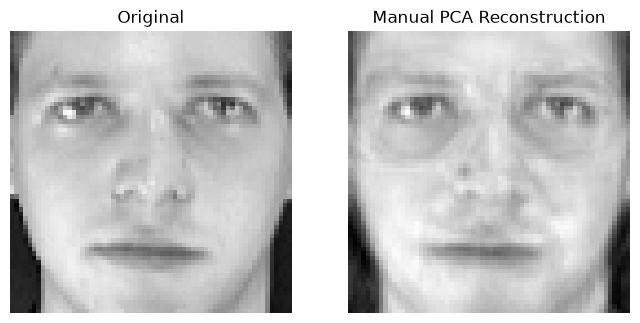

In [151]:
# display manual reconstruction
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    X[0].reshape(64, 64),
    cmap="gray"
)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    X_reconstructed_manual[0].reshape(64, 64),
    cmap="gray"
)
plt.title("Manual PCA Reconstruction")
plt.axis("off")

plt.show()